In [1]:
import tensorflow as tf

2024-09-12 16:19:03.071628: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Neural Network with TensorFlow

## Let's train Boston housing dataset

The Boston Housing dataset is a well-known dataset that is often used for regression tasks. It consists of data collected by the U.S. Census Service concerning housing in the area of Boston, Massachusetts.

Features
The dataset contains 13 features (input variables) for each instance:

CRIM: Per capita crime rate by town.

ZN: Proportion of residential land zoned for lots over 25,000 sq. ft.

INDUS: Proportion of non-retail business acres per town.

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise).

NOX: Nitric oxide concentration (parts per 10 million).

RM: Average number of rooms per dwelling.

AGE: Proportion of owner-occupied units built prior to 1940.

DIS: Weighted distances to five Boston employment centers.

RAD: Index of accessibility to radial highways.

TAX: Full-value property tax rate per $10,000.

PTRATIO: Pupil-teacher ratio by town.

B: Bk is the proportion of Black residents by town.

LSTAT: Percentage of lower status of the population.

Target
MEDV: Median value of owner-occupied homes in $1000s (this is the target variable).


In [2]:
from tensorflow.keras import datasets

dir(datasets)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'boston_housing',
 'cifar10',
 'cifar100',
 'fashion_mnist',
 'imdb',
 'mnist',
 'reuters']

In [3]:
from tensorflow.keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(404, 13)
(102, 13)
(404,)
(102,)


In [4]:
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(X_train, columns=feature_names)
df['MEDV'] = y_train

# Display the DataFrame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


In [5]:
# Standardize the data (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
X_train.shape

(404, 13)

In [7]:
from tensorflow.keras import layers, models, callbacks

# Define a simple neural network
model = models.Sequential([
    # Number of Neurons (Units), activation function, input shape
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # input layer
    layers.Dropout(0.2),    # Hidden layer
    layers.Dense(1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

# Define callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

# Display the model architecture
model.summary()

# Start Training
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 961 (3.75 KB)
Trainable params: 961 (3.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/500
11/11 [==============================] - 1s 43ms/step - loss: 581.1187 - mae: 22.1318 - val_loss: 645.8573 - val_mae: 23.6124
Epoch 2/500
11/11 [==============================] - 0s 7ms/step - loss: 562.7316 - mae: 21.7242 - val_loss: 627.1807 - val_mae: 23.2126
Epoch 3/500
11/

In [10]:
# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test)
train_loss, train_mae = model.evaluate(X_train, y_train)

print(f"\nTest MAE: {test_mae :.2f}")
print(f"\nTraining MAE: {train_mae :.2f}")

13/13 [==============================] - 0s 1ms/step - loss: 10.5212 - mae: 2.2707

Test MAE: 3.23

Training MAE: 2.27


## Let's do the prediction

1/1 [==============================] - 0s 37ms/step
Prediction :  [[13.92828]]
True Value: 7.2
Predicted Value: 13.93


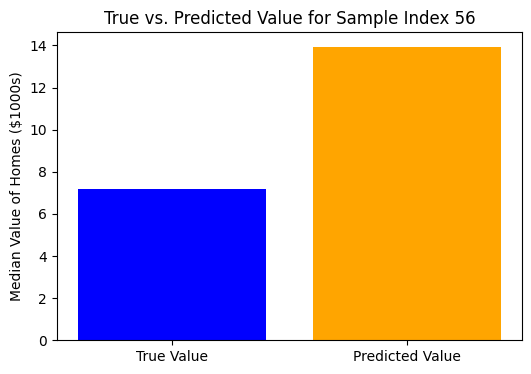

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Select a sample index
sample_index = 56  # Change this index to see different samples

# Get the sample features and true value
sample_features = X_test[sample_index].reshape(1, -1)
true_value = y_test[sample_index]

# Make a prediction
prediction = model.predict(sample_features)
print("Prediction : ", prediction)
predicted_value = prediction[0, 0]

# Display the true vs. predicted value
print(f"True Value: {true_value}")
print(f"Predicted Value: {predicted_value:.2f}")

# Visualize the true vs. predicted value
plt.figure(figsize=(6, 4))
plt.bar(['True Value', 'Predicted Value'], [true_value, predicted_value], color=['blue', 'orange'])
plt.title(f"True vs. Predicted Value for Sample Index {sample_index}")
plt.ylabel('Median Value of Homes ($1000s)')
plt.show()


****************************************************************

****************************************************************

****************************************************************